**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

*Edición 2025*

Mentoría 17 - Inventarios Forestales Nacionales, calculo de biomasa y evaluación del estado de los bosques nativos.

**GRUPO 1**

**Integrantes:**

- *Ana Luz Alabi Nassr*
- *Guillermo Poggioni*

**Mentor:**

- *Anibal Cuchietti*


----

### Práctico 3 de aprendizaje supervisado o no supervisado
**Consigna:**
> Estimar la altura de los arboles fuera de rango o con datos faltantes usando distintos modelos de regresion para encontrar el mas adecuado  segun la naturaleza de los datos seleccionados. 

----

## Introducción:
#### Para cumplir con la consigna del entregable seguiremos estos pasos:
> ----
>1. Variable objetivo: ALTURA_TOTAL_M.
>2. Copia de trabajo: crearemos una copia del dataset para explorarlo, curarlo y usarlo en los modelos.
>3. Tratamiento de valores extremos (outliers): definiremos outliers en la variable objetivo usando el umbral del cuantil 0.99. Los valores por encima de ese límite se convertirán en NaN. El subconjunto con NaN en la variable objetivo constituirá el conjunto a predecir.
>4. Partición de datos: el resto de los registros (con objetivo no nulo) se dividirá en Entrenamiento (70 %) y Validación (30 %).
>5. Modelado (tarea de regresión): intentaremos predecir ALTURA_TOTAL_M con:
>    - Random Forest Regressor.
>    - XGBoost Regressor.
>    - XGBRFR Regressor.
>6. Evaluación y explicabilidad: compararemos los modelos y seleccionaremos el mejor según métricas de regresión (p. ej., MAE, RMSE, R²).
>7. Integración de resultados: generaremos ALTURA_TOTAL_EST_FINAL en el dataset original, combinando:
>    - valores verdaderos de Entrenamiento,
>    - valores verdaderos de Validación,
>    - predicciones del Mejor Modelo para los registros con objetivo ausente.
> ----

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb
import missingno as msno
import xgboost as xgb

from sklearn.model_selection        import train_test_split, GridSearchCV, StratifiedKFold, KFold, RandomizedSearchCV
from xgboost                        import XGBRegressor, XGBRFRegressor
from sklearn.ensemble               import RandomForestRegressor
from sklearn.metrics                import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score
from sklearn.impute                 import SimpleImputer
from sklearn.preprocessing          import PowerTransformer, StandardScaler, RobustScaler
from sklearn.pipeline               import Pipeline


## Lectura del dataset

In [2]:
url2 = 'https://raw.githubusercontent.com/poggiogu/DiploDatos2025_Mentoria_17/refs/heads/master/Data/data_individuos_pais_2021.csv'
df_individuos = pd.read_csv(url2, low_memory=False)
#df_individuos.head(3)
df_individuos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101229 entries, 0 to 101228
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   UM_ID_UM                    101229 non-null  int64  
 1   NO_INDIV                    101229 non-null  int64  
 2   PARCELA_CONCENTRICA         101229 non-null  object 
 3   ESPECIE_CORREGIDA           101229 non-null  object 
 4   REGION_OFC                  101229 non-null  object 
 5   SUBREG                      96093 non-null   object 
 6   ESTADO_INDIV                101229 non-null  object 
 7   ALTURA_TOTAL_M              101226 non-null  float64
 8   PROVINCIA                   101229 non-null  int64  
 9   COORDENADAS_GPS_LATITUDE2   101229 non-null  float64
 10  COORDENADAS_GPS_LONGITUDE2  101229 non-null  float64
 11  DAP_FINAL_M                 101229 non-null  float64
 12  ALTURA_TOTAL_EST            101229 non-null  float64
 13  VOL_M3        

In [3]:
# creamos un DF copia para poder alterar y realizar comparaciones en bloques de código posteriores:
df_individuos_c = df_individuos.copy()

#### Observamos y eliminamos variables con baja cantidad de valores no nulos o con información redundante

<Axes: >

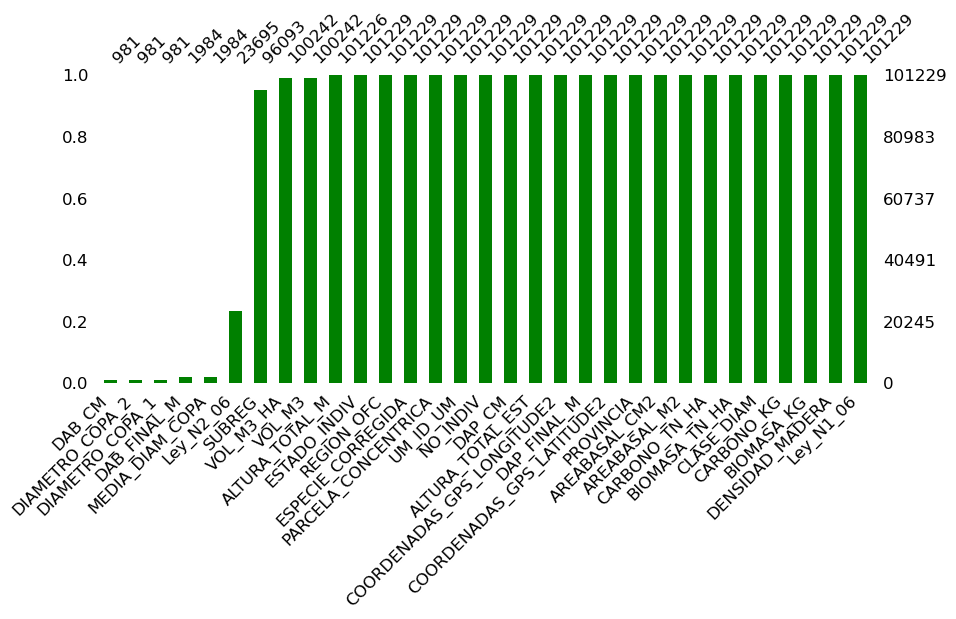

In [4]:
msno.bar(df_individuos_c, figsize=(10, 4), sort="ascending",fontsize=12, color='green')

In [5]:
# Dropeamos las columnas que no vamos a usar
df_filtrado_G = df_individuos_c.drop(columns=[
    'DIAMETRO_COPA_2',
    'DIAMETRO_COPA_1',
    'DAB_CM',
    'DAB_FINAL_M',
    'MEDIA_DIAM_COPA',
    'CARBONO_KG',
    'BIOMASA_KG',
    'AREABASAL_M2',
    'VOL_M3',
    'VOL_M3_HA',
    'DAP_CM',
    'Ley_N2_06',
    'SUBREG',
    'ALTURA_TOTAL_EST',
    'CARBONO_TN_HA',
    'CLASE_DIAM',
    'COORDENADAS_GPS_LATITUDE2',
    'COORDENADAS_GPS_LONGITUDE2'
    ])

print(f'Shape Antes: {df_individuos_c.shape}')
print(f'Shape Después: {df_filtrado_G.shape}')

Shape Antes: (101229, 31)
Shape Después: (101229, 13)


<Axes: >

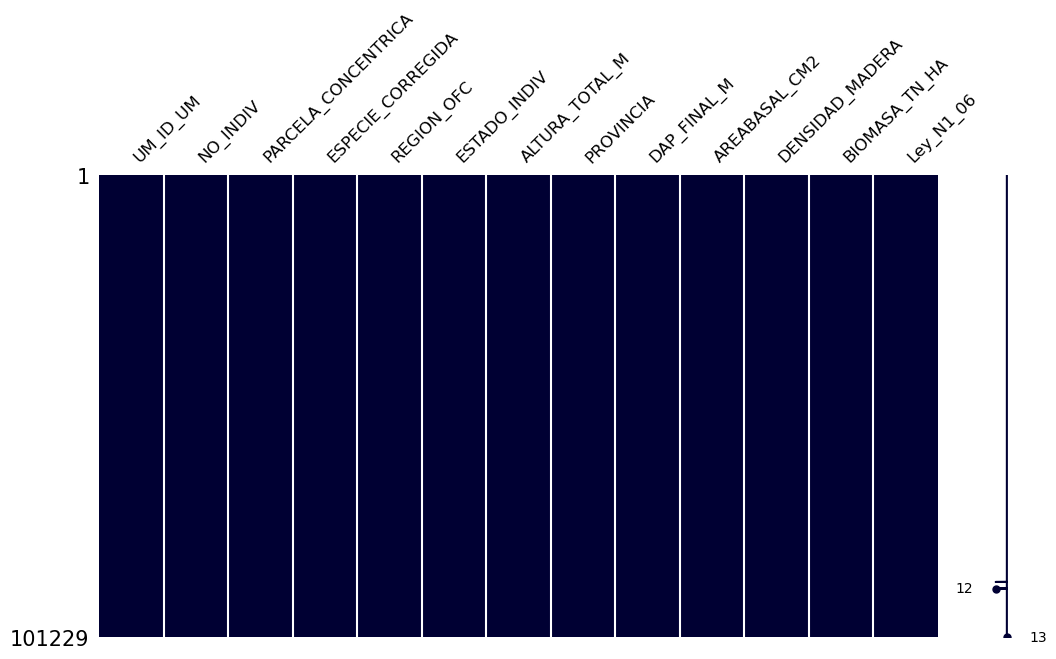

In [6]:
msno.matrix(df_filtrado_G,figsize=(12, 6), fontsize=12, color=[0,0,0.2])

In [7]:
len(df_filtrado_G[(df_filtrado_G['ESPECIE_CORREGIDA'] == 'UNLISTED')])

530

### Boxplots de las variables de "ALTURA" de los individuos en todo el dataset

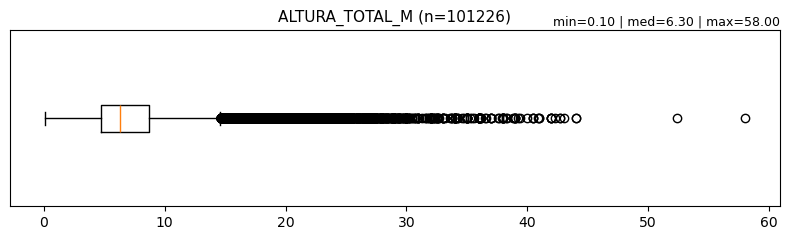

In [8]:
cols = ['ALTURA_TOTAL_M']
fig, axes = plt.subplots(len(cols), 1, figsize=(8, 2.5*len(cols)))
axes = np.atleast_1d(axes)

for ax, col in zip(axes, cols):
    s = df_filtrado_G[col].dropna()
    ax.boxplot(s, vert=False)  # simple, horizontal
    ax.set_title(f"{col} (n={len(s)})", fontsize=11)
    ax.set_yticks([])

    # Min/Med/Max
    mn, md, mx = float(s.min()), float(s.median()), float(s.max())
    ax.text(1.0, 1.05, f"min={mn:.2f} | med={md:.2f} | max={mx:.2f}",
            ha="right", va="center", transform=ax.transAxes, fontsize=9)

plt.tight_layout()
plt.show()

### Analizamos los outliers de 'ALTURA_TOTAL_M' por región ya que entendemos que las distribuciones de ALTURA difieren ampliamente según cada clase de 'REGION_OFC' 

In [9]:
df = df_filtrado_G
TARGET = "ALTURA_TOTAL_M"
REGION = "REGION_OFC"
# definimos el cuantil para el calculo del umbral
Q = 0.99

# Umbral p99 por región
df["_p99_region"] = df.groupby(REGION)[TARGET].transform(lambda s: s.quantile(Q))

# Flag de outlier
df["_es_outlier_p99_reg"] = df[TARGET] > df["_p99_region"]

resumen = (
    df.groupby(REGION)
      .agg(n=(TARGET,"size"),
           p99=(TARGET, lambda s: s.quantile(Q)),
           outliers=("_es_outlier_p99_reg","sum"))
      .assign(outlier_rate=lambda d: d["outliers"]/d["n"])
      .sort_values("outlier_rate", ascending=False)
)
resumen.head(10)

,n,p99,outliers,outlier_rate
REGION_OFC,,,,
BAP,6908,32.979,70,0.010133
MON,1984,7.817,20,0.010081
STB,5136,27.500,50,0.009735
ESP,7008,13.300,68,0.009703
DEL,628,20.000,6,0.009554
SMI,3079,26.700,29,0.009419
PCH,76486,15.000,716,0.009361


In [10]:
resumen['outliers'].sum()

np.int64(959)

#### Boxplots con outliers por región

<Figure size 1000x500 with 0 Axes>

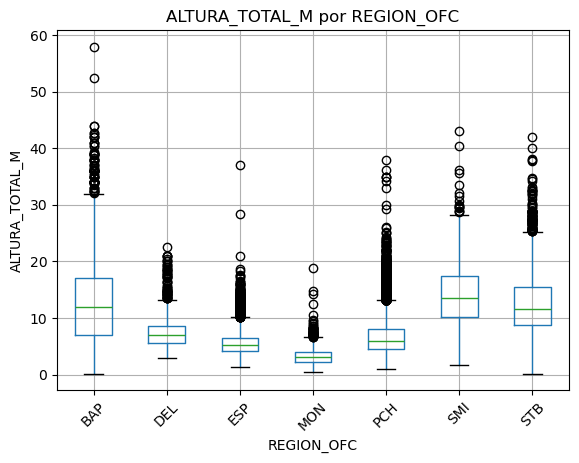

In [11]:
plt.figure(figsize=(10,5))
df.boxplot(column=TARGET, by=REGION, rot=45)
plt.title(f"{TARGET} por {REGION}")
plt.suptitle("")
plt.xlabel(REGION); plt.ylabel(TARGET)
plt.show()

In [12]:
df_sanit = df.copy()
df_sanit.loc[df_sanit["_es_outlier_p99_reg"], TARGET] = np.nan

In [13]:
print("Cantidad de registros con datos NaNs para ALTURA_TOTAL_M: ", len(df_sanit[df_sanit[TARGET].isna()]))

Cantidad de registros con datos NaNs para ALTURA_TOTAL_M:  962


Visualizamos nuevamente los boxplots de varaibles de ALTURA general de dataset

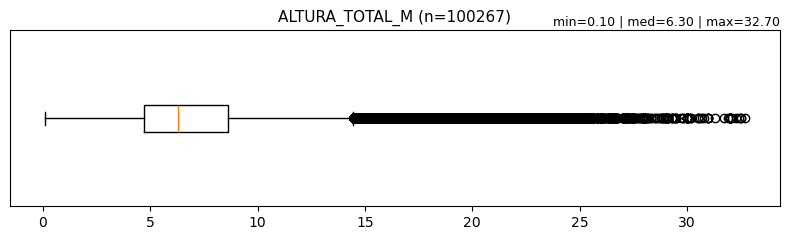

In [14]:
cols = ['ALTURA_TOTAL_M']
fig, axes = plt.subplots(len(cols), 1, figsize=(8, 2.5*len(cols)))
axes = np.atleast_1d(axes)

for ax, col in zip(axes, cols):
    s = df_sanit[col].dropna()
    ax.boxplot(s, vert=False)  # simple, horizontal
    ax.set_title(f"{col} (n={len(s)})", fontsize=11)
    ax.set_yticks([])

    mn, md, mx = float(s.min()), float(s.median()), float(s.max())
    ax.text(1.0, 1.05, f"min={mn:.2f} | med={md:.2f} | max={mx:.2f}",
            ha="right", va="center", transform=ax.transAxes, fontsize=9)

plt.tight_layout()
plt.show()

Y tambien los boxplots por region nuevamente

<Figure size 1000x500 with 0 Axes>

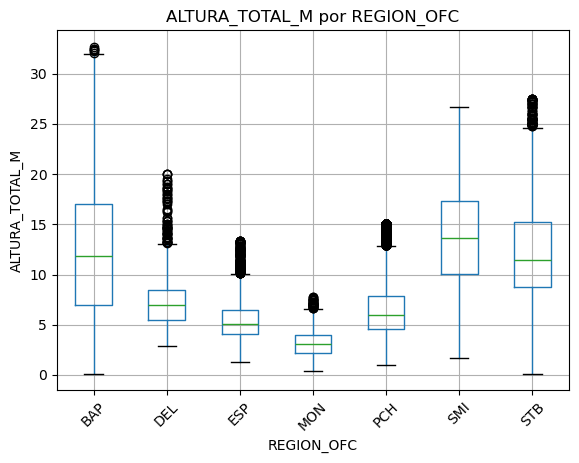

In [15]:
plt.figure(figsize=(10,5))
df_sanit.boxplot(column=TARGET, by=REGION, rot=45)
plt.title(f"{TARGET} por {REGION}")
plt.suptitle("")
plt.xlabel(REGION); plt.ylabel(TARGET)
plt.show()

#### Aplicamos OneHot encoding para aumentar la información disponible para nuestros modelos de regresión convirtiendo variables categóricas en numéricas.

 Determinamos las columnas a las que le aplicaremos One Hot Encoding. Utilizamos variables categóricas relevantes para nuestros futuros modelos y que a su vez no tengan un alto numero de clases, así podemos información util sin aumentar demasiado el número de dimensiones en el dataframe.

In [16]:
cols_onehot = ['REGION_OFC', 'Ley_N1_06', 'PARCELA_CONCENTRICA']
df_ind_onehot = pd.get_dummies(df_sanit, columns=cols_onehot, drop_first=False, dtype='int')
print(f'Cantidad de columnas antes del encoding: {df_sanit.shape[1]}')
print(f'Cantidad de columnas después del encoding: {df_ind_onehot.shape[1]}')


Cantidad de columnas antes del encoding: 15
Cantidad de columnas después del encoding: 24


Convertimos la variable ESTADO_IND a variable de tipo numérica y eliminamos posibles nans:

In [17]:
s = df_ind_onehot['ESTADO_INDIV'].astype(str).str.strip().replace({'-': None, '': None})
df_ind_onehot['ESTADO_INDIV'] = pd.to_numeric(s, errors='coerce').astype('Int64')
df_ind_onehot['ESTADO_INDIV'] = df_ind_onehot['ESTADO_INDIV'].fillna(0).astype(int) # llenamos los NaNs con 0
# Corroboramos que no tenga NaNs
df_ind_onehot['ESTADO_INDIV'].value_counts(dropna=False)

ESTADO_INDIV
1    70448
2    20366
3     7942
4     1713
0      760
Name: count, dtype: int64

In [18]:
columnas_num_oh= df_ind_onehot.select_dtypes(include=['number']).columns.tolist()
columnas_cat_oh = df_ind_onehot.select_dtypes(exclude=['number']).columns.tolist()

print("Columnas numéricas:", columnas_num_oh)
print("Columnas categóricas:", columnas_cat_oh)

Columnas numéricas: ['UM_ID_UM', 'NO_INDIV', 'ESTADO_INDIV', 'ALTURA_TOTAL_M', 'PROVINCIA', 'DAP_FINAL_M', 'AREABASAL_CM2', 'DENSIDAD_MADERA', 'BIOMASA_TN_HA', '_p99_region', 'REGION_OFC_BAP', 'REGION_OFC_DEL', 'REGION_OFC_ESP', 'REGION_OFC_MON', 'REGION_OFC_PCH', 'REGION_OFC_SMI', 'REGION_OFC_STB', 'Ley_N1_06_OT', 'Ley_N1_06_OTF', 'Ley_N1_06_TF', 'PARCELA_CONCENTRICA_A', 'PARCELA_CONCENTRICA_B']
Columnas categóricas: ['ESPECIE_CORREGIDA', '_es_outlier_p99_reg']


In [19]:
df_ind_onehot[columnas_cat_oh].nunique()

ESPECIE_CORREGIDA      458
_es_outlier_p99_reg      2
dtype: int64

#### Analizamos la matriz de correlación de las variables numéricas más importantes

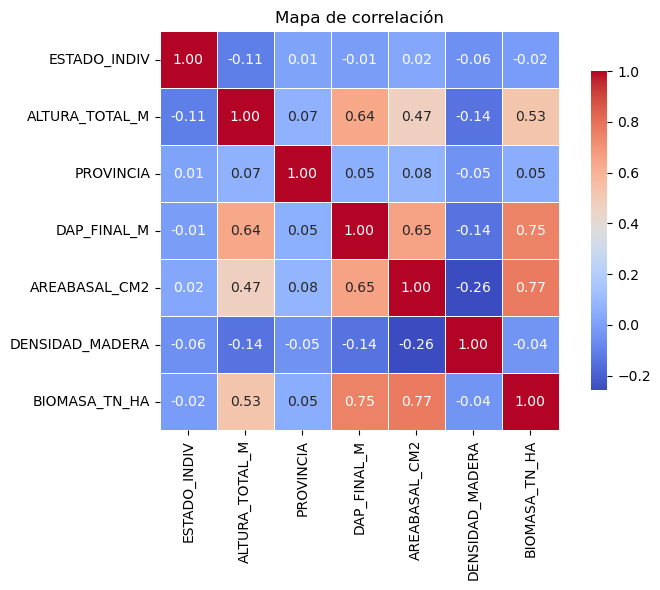

In [20]:
columnas_num_heatmap = ['ESTADO_INDIV', 'ALTURA_TOTAL_M', 'PROVINCIA','DAP_FINAL_M', 'AREABASAL_CM2', 'DENSIDAD_MADERA', 'BIOMASA_TN_HA']
df_corr = df_ind_onehot[columnas_num_heatmap].dropna()

# Calcular la matriz de correlación
corr_matrix = df_corr.corr(method='pearson')

plt.figure(figsize=(8,6))
sb.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True,
            cbar_kws={"shrink": 0.8}, linewidths=0.5)
plt.title("Mapa de correlación")
plt.tight_layout()
plt.show()

----
----

### Generamos nuestros datasets de Entrenamiento y Test

In [21]:
train_df = df_ind_onehot[columnas_num_oh][df_ind_onehot['ALTURA_TOTAL_M'].notna()].copy()
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100267 entries, 0 to 101228
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   UM_ID_UM               100267 non-null  int64  
 1   NO_INDIV               100267 non-null  int64  
 2   ESTADO_INDIV           100267 non-null  int64  
 3   ALTURA_TOTAL_M         100267 non-null  float64
 4   PROVINCIA              100267 non-null  int64  
 5   DAP_FINAL_M            100267 non-null  float64
 6   AREABASAL_CM2          100267 non-null  float64
 7   DENSIDAD_MADERA        100267 non-null  float64
 8   BIOMASA_TN_HA          100267 non-null  float64
 9   _p99_region            100267 non-null  float64
 10  REGION_OFC_BAP         100267 non-null  int64  
 11  REGION_OFC_DEL         100267 non-null  int64  
 12  REGION_OFC_ESP         100267 non-null  int64  
 13  REGION_OFC_MON         100267 non-null  int64  
 14  REGION_OFC_PCH         100267 non-null  i

In [22]:
y = train_df.ALTURA_TOTAL_M
X = train_df.drop('ALTURA_TOTAL_M',axis=1)
print(y.head(3))
X.head(3)

0    4.2
1    4.8
2    4.4
Name: ALTURA_TOTAL_M, dtype: float64


,UM_ID_UM,NO_INDIV,ESTADO_INDIV,PROVINCIA,DAP_FINAL_M,AREABASAL_CM2,DENSIDAD_MADERA,BIOMASA_TN_HA,_p99_region,REGION_OFC_BAP,...,REGION_OFC_ESP,REGION_OFC_MON,REGION_OFC_PCH,REGION_OFC_SMI,REGION_OFC_STB,Ley_N1_06_OT,Ley_N1_06_OTF,Ley_N1_06_TF,PARCELA_CONCENTRICA_A,PARCELA_CONCENTRICA_B
0,6074195,1,2,6,0.118381,110.065699,0.792,0.270712,7.817,0,...,0,1,0,0,0,0,1,0,1,0
1,6074195,3,3,6,0.101607,81.084506,0.715,0.207121,7.817,0,...,0,1,0,0,0,0,1,0,1,0
2,6074195,8,4,6,0.082219,53.092916,0.715,0.125851,7.817,0,...,0,1,0,0,0,0,1,0,1,0


Este dataframe de "Test" es el que tiene los registros con valores NaN para la variable TARGET, y en la cual vamos a estimarlos luego de entrenar y evaluar nuestros modelos.

In [23]:
test_df = df_ind_onehot[columnas_num_oh][df_ind_onehot['ALTURA_TOTAL_M'].isna()].copy()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 962 entries, 171 to 101036
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   UM_ID_UM               962 non-null    int64  
 1   NO_INDIV               962 non-null    int64  
 2   ESTADO_INDIV           962 non-null    int64  
 3   ALTURA_TOTAL_M         0 non-null      float64
 4   PROVINCIA              962 non-null    int64  
 5   DAP_FINAL_M            962 non-null    float64
 6   AREABASAL_CM2          962 non-null    float64
 7   DENSIDAD_MADERA        962 non-null    float64
 8   BIOMASA_TN_HA          962 non-null    float64
 9   _p99_region            962 non-null    float64
 10  REGION_OFC_BAP         962 non-null    int64  
 11  REGION_OFC_DEL         962 non-null    int64  
 12  REGION_OFC_ESP         962 non-null    int64  
 13  REGION_OFC_MON         962 non-null    int64  
 14  REGION_OFC_PCH         962 non-null    int64  
 15  REGION

In [24]:
# eliminamos la columna objetivo del set test_df
# porque lo vamos a predecir al final del TP3
test_df = test_df.drop(columns=['ALTURA_TOTAL_M'])

A partir de los datos en las variables `X` e `y` separamos en train y en test:

In [25]:
RANDOM_STATE = 42 #Mantenemos siempre el mismo random state para poder reproducir
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state = RANDOM_STATE)

Vemos rapidamente como quedaron nuestras distribuciones:

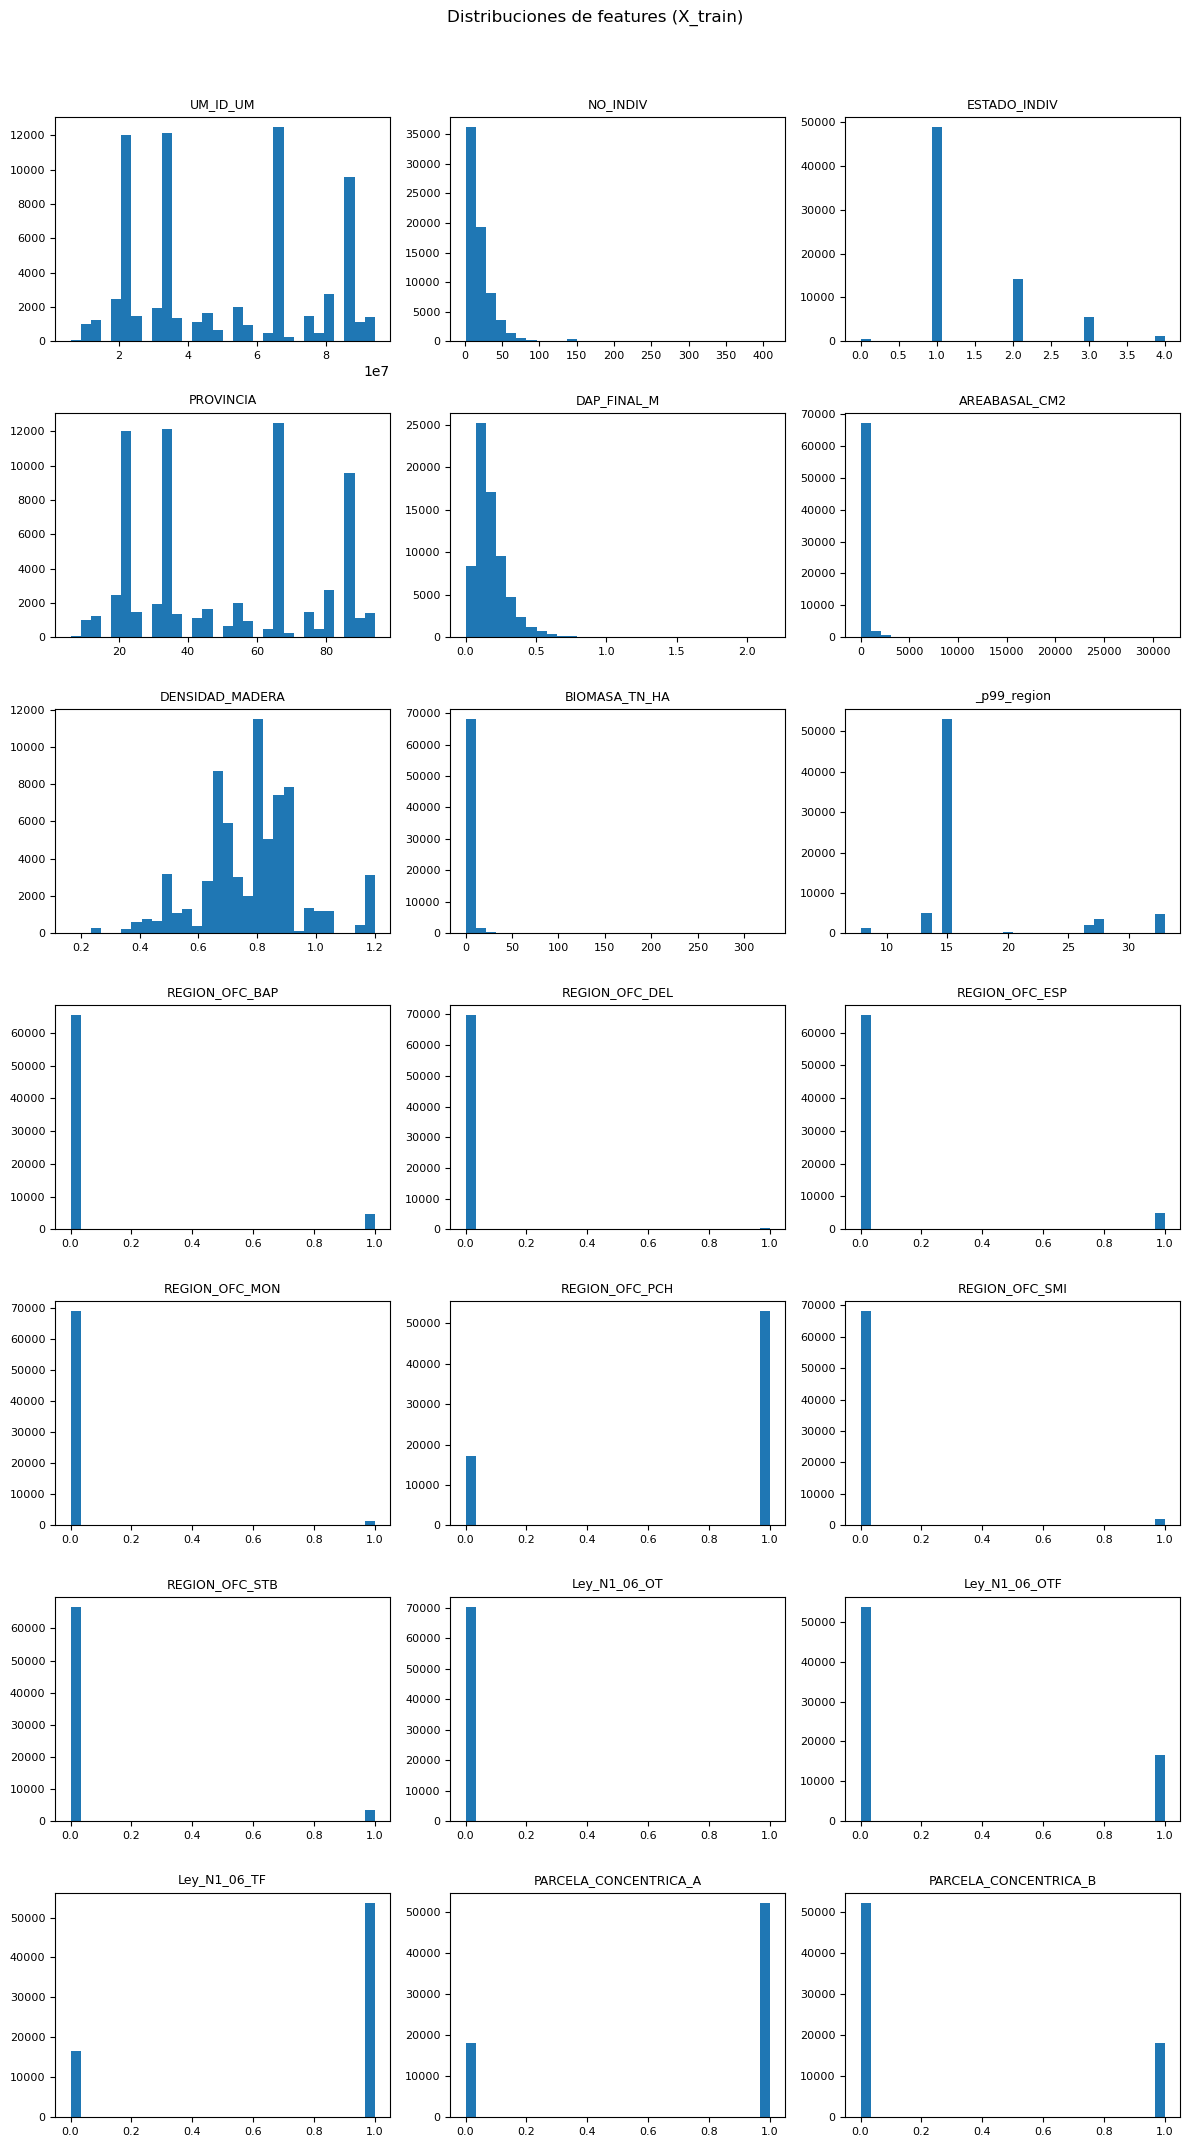

In [26]:
import math

feature_names = [f"f_{i:02d}" for i in range(X_train.shape[1])]

n = X_train.shape[1]         # 21 variables 
ncols = 3                    # 3 columnas por fila
nrows = math.ceil(n / ncols) # 7 filas

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3), sharex=False, sharey=False)
axes = axes.ravel()

for i, col in enumerate(X_train.columns):
    axes[i].hist(X_train[col].dropna(), bins=30)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=8)

fig.suptitle("Distribuciones de features (X_train)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

>**NOTA:** *Vemos que las distribuciones de las variables NO_INDIV, DAP_FINAL_M, AREABASAL_CM2 y BIOMASA_TN_HA son sesgadas con una considerable cola hacia la derecha, pero para los modelos de árboles (RF/XGB/XGBRF) que vamos a implementar, en general no les afecta porque usan órdenes/umbrales, motivo por el cual decidimos no escalar o suavizar las distribuciones.*

----
----

## Planteo de los Modelos de regresión

- Vamos a implementar **Random Forest**, **XGBoost** y **XGRFBoost**.
- En cada caso usaremos Search para identificar la mejor combinación de hiperparámetros: 
    - RandomizedSearchCV para Random Forest  
    - GridSearchCV para XGBoost y XGRFBoost

----
### Random Forest

In [27]:
# RandomizedSearchCV
# Con esta config demora unos 8' en mi ambiente local (procesador AMD Ryzen-7 3.4GHZ/ 16GB Ram )
rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=1,                 
    bootstrap=True,
    n_estimators=200,        
    max_samples=0.8          
)

param_dist_rf = {
    "max_depth": [None, 16, 20],
    "min_samples_split": [2, 5,],
    "min_samples_leaf": [1, 4],
    #"max_features": ["sqrt", "log2", 0.7, 1.0]
}

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE) # Lo bajé a n_splits = 3 para mejorar un poco el rendimiento en el local

rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,                         
    refit=True,
    verbose=1,
    random_state=RANDOM_STATE
)

rs.fit(X_train, y_train)

print("Mejores params:", rs.best_params_)
y_pred = rs.best_estimator_.predict(X_test)
print(
    f"[TEST] MAE={mean_absolute_error(y_test, y_pred):.4f}  "
    f"RMSE={mean_squared_error(y_test, y_pred):.4f}  "
    f"R²={r2_score(y_test, y_pred):.4f}"
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejores params: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
[TEST] MAE=0.3820  RMSE=1.0636  R²=0.9291


Instanciamos el modelo de Random Forest con la combinación de hiperparámetros encontraInstanciamos el modelo de Random Forest con la combinación de hiperparámetros encontrada con RandomizedSearchCV

In [28]:
# Mejores params: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
best_model_rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=1,                 
    bootstrap=True,
    n_estimators=1000, # aumento el num de estimadores para el modelo final de RF (se puso un poco más lento con esto)       
    max_samples=0.8, 
    min_samples_split = 2, # **
    min_samples_leaf = 1, # **
    max_depth = None # **
)

## ** coinciden con los valore por defecto pero los dejo en el modelo para verlos

In [29]:
# Entrenamiento 7 - 8 minutos 
best_model_rf.fit(X_train, y_train)

RandomForestRegressor(max_samples=0.8, n_estimators=1000, n_jobs=1,
                      random_state=42)

In [30]:
# Predicciones
rf_y_pred_train = best_model_rf.predict(X_train)
rf_y_pred_test = best_model_rf.predict(X_test)

Evaluación del modelo comparando conjuntos de train y test

In [31]:
def eval_reg(y_true, y_pred):
    ae = np.abs(y_true - y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred),
        "MedAE": median_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "P90_AE": np.percentile(ae, 90),
        "P95_AE": np.percentile(ae, 95),
    }

rf_metrics_train = eval_reg(y_train, rf_y_pred_train)
rf_metrics_test  = eval_reg(y_test,  rf_y_pred_test)

print("Métricas para el modelo de Random Forest Regressor: ")
print(pd.DataFrame([rf_metrics_train, rf_metrics_test], index=["train","test"]).round(4))

Métricas para el modelo de Random Forest Regressor: 
          MAE    RMSE   MedAE      R2  P90_AE  P95_AE
train  0.1675  0.2086  0.0390  0.9860  0.3978  0.7764
test   0.3792  1.0570  0.0866  0.9295  0.8817  1.8096


----
### XGBoost Regressor

In [32]:
# Grid Search
xgb = XGBRegressor(
    random_state=RANDOM_STATE,
    tree_method="hist",
    n_estimators=800,
    eval_metric="mae",
    verbosity=1
)

param_grid = {
    "max_depth": [4, 8],
    "learning_rate": [0.03, 0.1],
    "min_child_weight": [1, 5],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0],
    #"reg_lambda": [0.0, 2.0],
    #"reg_alpha": [0.0, 1.0],
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gs_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

gs_xgb.fit(X_train, y_train)

print("Mejores params:", gs_xgb.best_params_)
y_pred = gs_xgb.best_estimator_.predict(X_test)
print(
    f"[TEST] MAE={mean_absolute_error(y_test, y_pred):.4f}  "
    f"RMSE={mean_squared_error(y_test, y_pred):.4f}  "
    f"R²={r2_score(y_test, y_pred):.4f}"
)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Mejores params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 1, 'subsample': 1.0}
[TEST] MAE=0.3477  RMSE=0.9939  R²=0.9337


Instanciamos el modelo de **XGBoost Regressor** con la combinación de hiperparámetros encontrados con GridSearchCV 

In [33]:
best_model_xgb = XGBRegressor(
    random_state=RANDOM_STATE,
    tree_method="hist",
    n_estimators=800,
    eval_metric="mae",
    verbosity=1,
    max_depth = 4,
    learning_rate = 0.03,
    min_child_weight = 1,
    subsample = 0.7
)

In [34]:
# Entrenamiento
best_model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='mae', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=None, num_parallel_tree=None, ...)

In [35]:
# Predicciones
xgb_y_pred_train = best_model_xgb.predict(X_train)
xgb_y_pred_test = best_model_xgb.predict(X_test)

Evaluación del modelo comparando conjuntos de train y test

In [36]:
def eval_reg(y_true, y_pred):
    ae = np.abs(y_true - y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred),
        "MedAE": median_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "P90_AE": np.percentile(ae, 90),
        "P95_AE": np.percentile(ae, 95),
    }

xgb_metrics_train = eval_reg(y_train, xgb_y_pred_train)
xgb_metrics_test  = eval_reg(y_test,  xgb_y_pred_test)

print("Métricas para el modelo de XGBoost: ")
print(pd.DataFrame([xgb_metrics_train, xgb_metrics_test], index=["train","test"]).round(4))

Métricas para el modelo de XGBoost: 
          MAE    RMSE   MedAE      R2  P90_AE  P95_AE
train  0.6671  1.3480  0.3843  0.9095  1.4763  2.2511
test   0.6971  1.5387  0.3884  0.8974  1.5265  2.4048


----
### XGBRFRegressor

In [37]:
# Grid Search
xgbrf = XGBRFRegressor(
    random_state=RANDOM_STATE,
    tree_method="hist",
    eval_metric="mae"
)

param_grid_xgbrfr = {
    #"n_estimators": [400, 800],
    "max_depth": [4, 6, 8],
    "min_child_weight": [1, 3],
    "subsample": [0.7, 1.0],
    "colsample_bynode": [0.5, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [0.0, 2.0],
    "gamma": [0, 1],
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gs_xgbrf = GridSearchCV(
    estimator=xgbrf,
    param_grid=param_grid_xgbrfr,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

gs_xgbrf.fit(X_train, y_train)

print("XGBRF — Mejores params:", gs_xgbrf.best_params_)

y_pred_xgbrf = gs_xgbrf.best_estimator_.predict(X_test)

print(f"XGBRF [TEST] MAE={mean_absolute_error(y_test, y_pred_xgbrf):.4f}  "
      f"RMSE={mean_squared_error(y_test, y_pred_xgbrf):.4f}  "
      f"R²={r2_score(y_test, y_pred_xgbrf):.4f}")

Fitting 5 folds for each of 192 candidates, totalling 960 fits
XGBRF — Mejores params: {'colsample_bynode': 1.0, 'colsample_bytree': 1.0, 'gamma': 0, 'max_depth': 8, 'min_child_weight': 3, 'reg_lambda': 0.0, 'subsample': 0.7}
XGBRF [TEST] MAE=0.9984  RMSE=2.5379  R²=0.8308


Instanciamos el modelo de **XGBRFRegressor** con la combinación de hiperparámetros encontrados con GridSearchCV 

In [38]:
# Mejores params: {'colsample_bynode': 1.0, 'colsample_bytree': 1.0, 'gamma': 0, 'max_depth': 8, 'min_child_weight': 3, 'reg_lambda': 0.0, 'subsample': 0.7}
best_model_xgbrfr = XGBRFRegressor(
    random_state=RANDOM_STATE,
    tree_method="hist",
    eval_metric="mae",
    colsample_bynode = 1.0,
    colsample_bytree = 1.0,
    gamma = 0,
    max_depth = 8,
    min_child_weight = 3,
    reg_lambda = 0.0,
    subsample = 0.7
)

In [39]:
# Entrenamiento
best_model_xgbrfr.fit(X_train, y_train)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=1.0,
               colsample_bytree=1.0, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='mae', feature_types=None,
               feature_weights=None, gamma=0, grow_policy=None,
               importance_type=None, interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=8, max_leaves=None,
               min_child_weight=3, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, objective='reg:squarederror', ...)

In [40]:
# Predicciones
xgbrfr_y_pred_train = best_model_xgbrfr.predict(X_train)
xgbrfr_y_pred_test = best_model_xgbrfr.predict(X_test)

Evaluación del modelo comparando conjuntos de train y test

In [41]:
def eval_reg(y_true, y_pred):
    ae = np.abs(y_true - y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred),
        "MedAE": median_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "P90_AE": np.percentile(ae, 90),
        "P95_AE": np.percentile(ae, 95),
    }

xgbrfr_metrics_train = eval_reg(y_train, xgbrfr_y_pred_train)
xgbrfr_metrics_test  = eval_reg(y_test,  xgbrfr_y_pred_test)

print("Métricas para el modelo de XGBRFRegressor: ")
print(pd.DataFrame([xgbrfr_metrics_train, xgbrfr_metrics_test], index=["train","test"]).round(4))

Métricas para el modelo de XGBRFRegressor: 
          MAE    RMSE   MedAE      R2  P90_AE  P95_AE
train  0.9638  2.3484  0.5958  0.8423  2.1561  3.0868
test   0.9984  2.5379  0.6180  0.8308  2.2440  3.2179


----
----

## Conclusión y predicción final

### Analizamos las métricas obtenidas en cada uno de los modelos implementados

In [42]:
print("Métricas para el modelo de Random Forest Regressor: ")
print(pd.DataFrame([rf_metrics_train, rf_metrics_test], index=["train","test"]).round(4))
print("********************************************************************")
print("Métricas para el modelo de XGBoost: ")
print(pd.DataFrame([xgb_metrics_train, xgb_metrics_test], index=["train","test"]).round(4))
print("********************************************************************")
print("Métricas para el modelo de XGBRFRegressor: ")
print(pd.DataFrame([xgbrfr_metrics_train, xgbrfr_metrics_test], index=["train","test"]).round(4))

Métricas para el modelo de Random Forest Regressor: 
          MAE    RMSE   MedAE      R2  P90_AE  P95_AE
train  0.1675  0.2086  0.0390  0.9860  0.3978  0.7764
test   0.3792  1.0570  0.0866  0.9295  0.8817  1.8096
********************************************************************
Métricas para el modelo de XGBoost: 
          MAE    RMSE   MedAE      R2  P90_AE  P95_AE
train  0.6671  1.3480  0.3843  0.9095  1.4763  2.2511
test   0.6971  1.5387  0.3884  0.8974  1.5265  2.4048
********************************************************************
Métricas para el modelo de XGBRFRegressor: 
          MAE    RMSE   MedAE      R2  P90_AE  P95_AE
train  0.9638  2.3484  0.5958  0.8423  2.1561  3.0868
test   0.9984  2.5379  0.6180  0.8308  2.2440  3.2179


#### El modelo de **Random Forest** fue con el cual obtuvimos los mejores resultados y será el que utilizaremos para la predicción final de la variable objetivo.

In [43]:
# creo un data frame final con una copia de "df_sanit" donde anteriormente 
# convertimos en nulos los valores extremos de 'ALTURA_TOTAL_M' por región
# para usarlo para la predicción.
df_final = df_sanit.copy()

In [ ]:
# Predicción final
rf_pred_final = best_model_rf.predict(test_df)
rf_pred_final.shape

(962,)

In [ ]:
# Agrego la predicción a los valores nulos de nuestro df_final
df_final.loc[df_final['ALTURA_TOTAL_M'].isna(), 'ALTURA_TOTAL_M'] = rf_pred_final

In [46]:
# Agregamos una columna final que incluye los valores originales de 
# 'ALTURA_TOTAL_M' más nuestras estimaciones para los valores nulos y 
# outliers determinados anteriormente para poder comparar las distribuciones
df_individuos_c['ALTURA_TOTAL_EST_FINAL'] = df_final['ALTURA_TOTAL_M'] 
df_individuos_c['ALTURA_TOTAL_EST_FINAL'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 101229 entries, 0 to 101228
Series name: ALTURA_TOTAL_EST_FINAL
Non-Null Count   Dtype  
--------------   -----  
101229 non-null  float64
dtypes: float64(1)
memory usage: 791.0 KB


#### Comparamos las distribuciones de las variables de 'ALTURA_TOTAL_M', 'ALTURA_TOTAL_EST' y la que incluye las predicciones de nuestro modelo ('ALTURA_TOTAL_EST_FINAL')

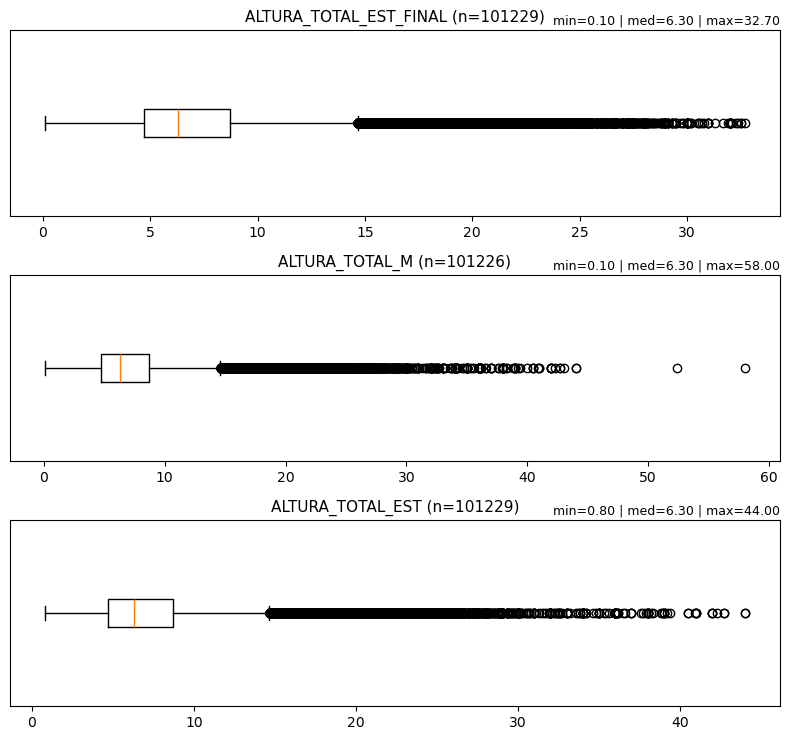

In [47]:
cols = ['ALTURA_TOTAL_EST_FINAL','ALTURA_TOTAL_M','ALTURA_TOTAL_EST']
fig, axes = plt.subplots(len(cols), 1, figsize=(8, 2.5*len(cols)))
axes = np.atleast_1d(axes)

for ax, col in zip(axes, cols):
    s = df_individuos_c[col].dropna()
    ax.boxplot(s, vert=False)  
    ax.set_title(f"{col} (n={len(s)})", fontsize=11)
    ax.set_yticks([])

    mn, md, mx = float(s.min()), float(s.median()), float(s.max())
    ax.text(1.0, 1.05, f"min={mn:.2f} | med={md:.2f} | max={mx:.2f}",
            ha="right", va="center", transform=ax.transAxes, fontsize=9)

plt.tight_layout()
plt.show()